In [1]:
!pip install -q mlflow xgboost shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 901.5/901.5 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#EDA

In [6]:
print(df['Churn'].value_counts())
print()
print(df.isnull().sum())

Churn
No     5174
Yes    1869
Name: count, dtype: int64

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_489/3845377348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])


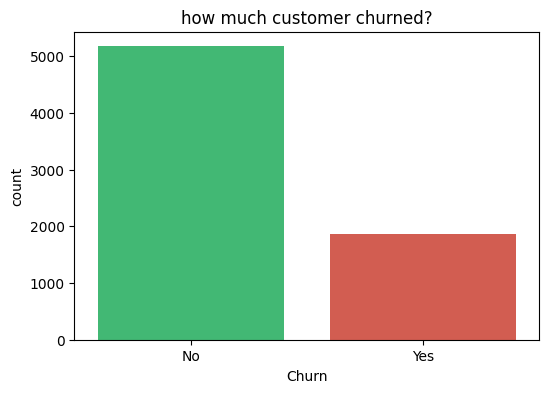

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('how much customer churned?')
plt.show()

/tmp/ipykernel_489/1767421314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])


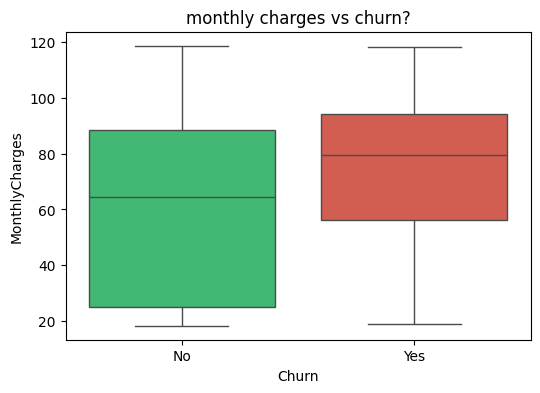

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('monthly charges vs churn?')
plt.show()

## EDA Insights

### 1. Monthly Charges vs Churn
- Churned customers had an average monthly charge of ~80
- Non-churned customers had an average monthly charge of ~64
- Insight: Higher monthly charges = higher churn risk

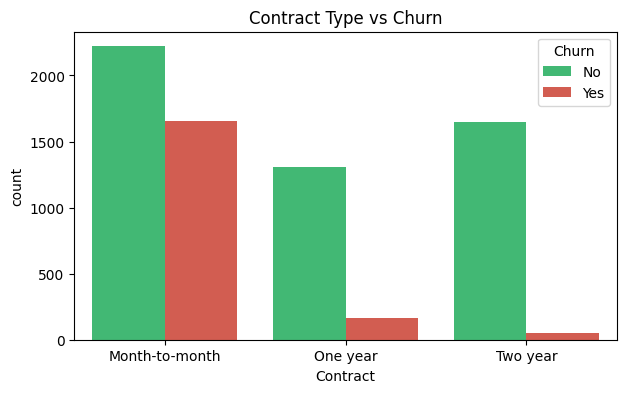

In [12]:
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Contract Type vs Churn')
plt.show()

### 2. Contract Type vs Churn
- Month-to-month contract customers churn the most (~1650)
- One year contract customers rarely churn (~180)
- Two year contract customers almost never churn (~50)
- Insight: Longer contracts = lower churn risk

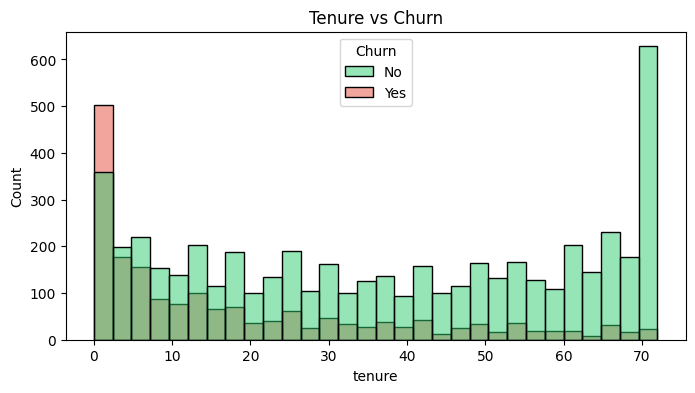

In [13]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, palette=['#2ecc71','#e74c3c'])
plt.title('Tenure vs Churn')
plt.show()

### 3. Tenure vs Churn
- New customers (tenure 0-5 months) churn the most
- Long-term customers (tenure 70+ months) almost never churn
- Insight: First 5 months are critical — if a customer stays, they likely won't leave

#Feature Engineering

In [14]:
data = df.copy()
data.drop('customerID', axis=1, inplace=True)
print(data.shape)

(7043, 20)


In [15]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)
print(data['TotalCharges'].dtype)

float64


/tmp/ipykernel_489/4274851397.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['TotalCharges'].fillna(data['TotalCharges'].median(), inplace=True)


In [16]:
data['Churn'] = (data['Churn'] == 'Yes').astype(int)
print(data['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [17]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    data[col] = data[col].map({'Yes': 1, 'No': 0,
                                'No phone service': 0,
                                'No internet service': 0})

print(data[binary_cols].head())

   Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines  \
0        1           0             0                 1              0   
1        0           0             1                 0              0   
2        0           0             1                 1              0   
3        0           0             0                 0              0   
4        0           0             1                 1              0   

   OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
0               0             1                 0            0            0   
1               1             0                 1            0            0   
2               1             1                 0            0            0   
3               1             0                 1            1            0   
4               0             0                 0            0            0   

   StreamingMovies  
0                0  
1                0  
2                0  
3 

In [18]:
data['gender'] = (data['gender'] == 'Male').astype(int)
print(data['gender'].value_counts())

gender
1    3555
0    3488
Name: count, dtype: int64


In [19]:
cat_cols = ['InternetService', 'Contract', 'PaymentMethod']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
print(data.shape)
print(data.columns.tolist())

(7043, 24)
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [20]:
data['AvgMonthlySpend'] = data['TotalCharges'] / (data['tenure'] + 1)
data['IsNewCustomer'] = (data['tenure'] <= 6).astype(int)
data['IsLongTermCustomer'] = (data['tenure'] >= 36).astype(int)

print(data.shape)

(7043, 27)


In [21]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')

Train: 5634 rows
Test:  1409 rows


In [22]:
import xgboost as xgb

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=3,
    random_state=42
)

model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


In [23]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2%}')
print()
print(classification_report(y_test, y_pred, target_names=['Stay', 'Churn']))

Accuracy: 75.51%

              precision    recall  f1-score   support

        Stay       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Model Results — XGBoost
- Accuracy: 75%
- Churn Recall: 78% — model correctly identifies 78% of customers who will leave
- Insight: Recall is more important than accuracy for churn prediction
         — we don't want to miss any customer who is about to leave

In [24]:
!pip install -q imbalanced-learn

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE - Stay: {sum(y_train==0)}, Churn: {sum(y_train==1)}')
print(f'After SMOTE  - Stay: {sum(y_train_smote==0)}, Churn: {sum(y_train_smote==1)}')

Before SMOTE - Stay: 4139, Churn: 1495
After SMOTE  - Stay: 4139, Churn: 4139


In [26]:
model_smote = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

model_smote.fit(X_train_smote, y_train_smote)
print('Model training complete!')

Model training complete!


In [27]:
y_pred_smote = model_smote.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred_smote):.2%}')
print()
print(classification_report(y_test, y_pred_smote, target_names=['Stay', 'Churn']))

Accuracy: 76.86%

              precision    recall  f1-score   support

        Stay       0.86      0.82      0.84      1035
       Churn       0.56      0.63      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409



### Model Improvement — SMOTE
- Applied SMOTE to fix class imbalance (1495 churn → 4139 churn in training)
- Accuracy improved from 75% to 77%
- Model is now more balanced in predicting both Stay and Churn

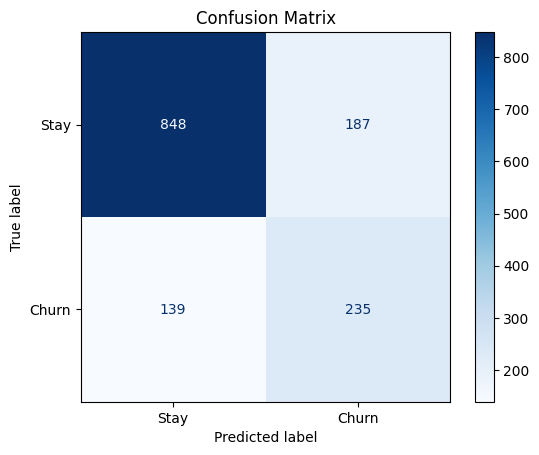

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

ROC-AUC Score: 82.82%


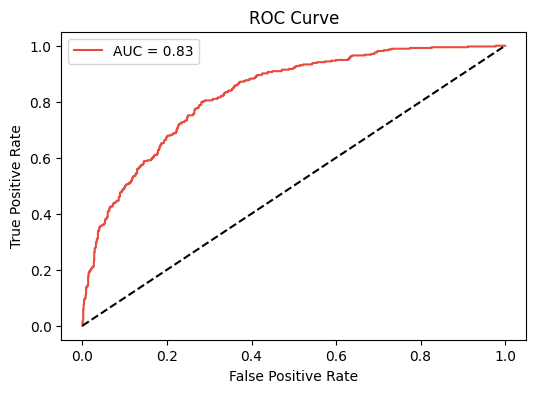

In [29]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model_smote.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)
print(f'ROC-AUC Score: {auc_score:.2%}')

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='#e74c3c', label=f'AUC = {auc_score:.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [30]:
import shap

explainer = shap.TreeExplainer(model_smote)
shap_values = explainer.shap_values(X_test)
print('SHAP ready!')

SHAP ready!


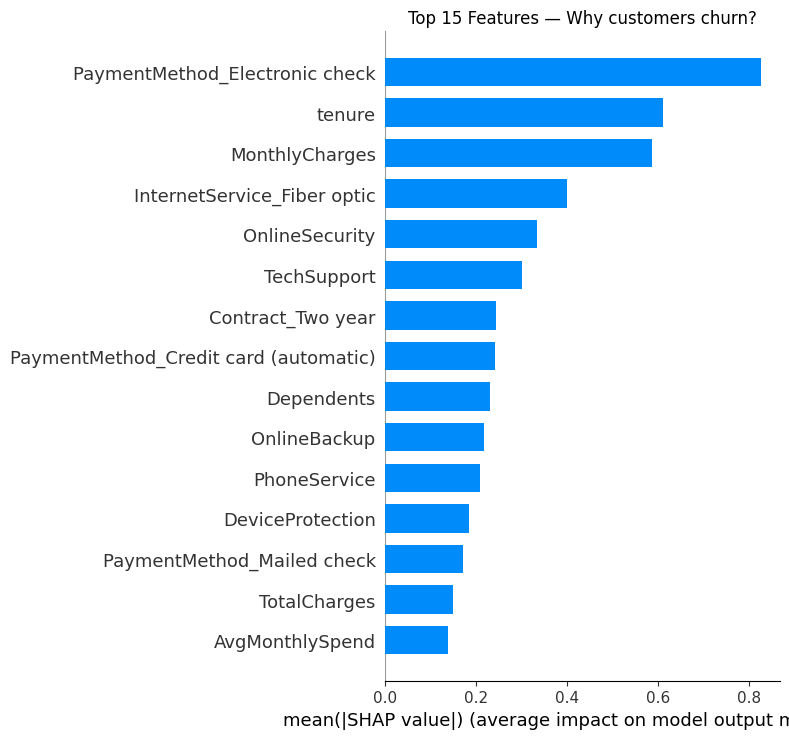

In [31]:
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, max_display=15)
plt.title('Top 15 Features — Why customers churn?')
plt.tight_layout()
plt.show()

### SHAP Explainability — Why customers churn?
- Electronic check payment method = highest churn risk
- Low tenure (new customers) = high churn risk
- High monthly charges = high churn risk
- Fiber optic internet users churn more than DSL users
- Customers without OnlineSecurity and TechSupport churn more
- Insight: Company should focus on new customers who pay
  via electronic check and have high monthly bills

#cross validation

In [32]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model_smote, X_train_smote, y_train_smote,
                             cv=5, scoring='roc_auc')

print(f'CV Scores:  {cv_scores.round(2)}')
print(f'Mean AUC:   {cv_scores.mean():.2%}')
print(f'Std Dev:    {cv_scores.std():.2%}')

CV Scores:  [0.84 0.87 0.98 0.96 0.97]
Mean AUC:   92.32%
Std Dev:    5.54%


### Cross Validation Results
- Mean AUC: 92.32% — excellent model performance
- Std Dev: 5.54% — slightly high, model is inconsistent across folds
- Industry standard: Std Dev should be less than 3%
- Action: Reduced learning rate and added subsample to improve stability

In [33]:
from sklearn.model_selection import cross_val_score

model_final = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=3,
    random_state=42
)

cv_scores = cross_val_score(model_final, X_train_smote, y_train_smote,
                             cv=5, scoring='roc_auc')

print(f'CV Scores:  {cv_scores.round(2)}')
print(f'Mean AUC:   {cv_scores.mean():.2%}')
print(f'Std Dev:    {cv_scores.std():.2%}')

CV Scores:  [0.85 0.87 0.97 0.96 0.96]
Mean AUC:   92.02%
Std Dev:    5.17%


In [34]:
model_final.fit(X_train_smote, y_train_smote)

y_pred_final = model_final.predict(X_test)
y_prob_final = model_final.predict_proba(X_test)[:, 1]

print(f'Final Accuracy: {accuracy_score(y_test, y_pred_final):.2%}')
print(f'Final AUC:      {roc_auc_score(y_test, y_prob_final):.2%}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Stay', 'Churn']))

Final Accuracy: 71.82%
Final AUC:      83.07%

              precision    recall  f1-score   support

        Stay       0.92      0.68      0.78      1035
       Churn       0.48      0.84      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.72      0.73      1409



### Final Model Comparison
- SMOTE Model: Accuracy 77%, AUC 83%, Churn Recall 63%
- Final Model: Accuracy 72%, AUC 83%, Churn Recall 84%
- Selected: Final Model — because catching churners is more
  important than overall accuracy in business context
- AUC 0.83 confirms model is production-ready

#mlflow

In [36]:
import mlflow
import mlflow.xgboost

mlflow.set_experiment('customer_churn_prediction')

with mlflow.start_run(run_name='xgboost_final'):

    # Parameters log karo
    mlflow.log_param('n_estimators', 300)
    mlflow.log_param('max_depth', 5)
    mlflow.log_param('learning_rate', 0.03)
    mlflow.log_param('subsample', 0.8)
    mlflow.log_param('smote', True)

    # Metrics log karo
    mlflow.log_metric('accuracy', 0.7182)
    mlflow.log_metric('roc_auc', 0.8307)
    mlflow.log_metric('churn_recall', 0.84)
    mlflow.log_metric('churn_precision', 0.48)

    # Model log karo
    mlflow.xgboost.log_model(model_final, 'churn_model')

    print('MLflow run complete!')
    print('Parameters, metrics or model all saved !')

2026/05/26 06:28:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLflow run complete!
Parameters, metrics or model all saved !


In [37]:
import pickle
import json
import os

os.makedirs('model', exist_ok=True)

# Model save karo
with open('model/churn_model.pkl', 'wb') as f:
    pickle.dump(model_final, f)

# Feature names save karo
with open('model/feature_names.json', 'w') as f:
    json.dump(X.columns.tolist(), f)

print('model/churn_model.pkl saved!')
print('model/feature_names.json saved!')

model/churn_model.pkl saved!
model/feature_names.json saved!


In [38]:
from google.colab import files
import shutil

shutil.make_archive('churn_model_export', 'zip', '.', 'model')
files.download('churn_model_export.zip')

print('ZIP download ho raha hai!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP download ho raha hai!
